# Week 4 — Day 5 : Introduction to Machine Learning
## XP Exercises — Loan Default Prediction & ML Design

**Student :** Leeroy Benaich  
**Bootcamp :** GenAI & Machine Learning — 2026  

---

## Exercise 1 — Problem Definition & Data Collection for Loan Default Prediction

### Problem Statement

**Objective :** Build a machine learning model that predicts whether a loan applicant will default on their loan repayment, based on their personal, financial, and credit history data.

A **loan default** occurs when a borrower fails to make required payments on a debt. For financial institutions, being able to predict defaults in advance allows them to:
- Reduce financial losses
- Make smarter lending decisions
- Offer appropriate interest rates based on risk

This is a **binary classification problem** : the target variable is `default` (1 = defaulted, 0 = repaid).

---

### Data Types Needed

| Category | Features | Type |
|---|---|---|
| **Personal info** | Age, gender, marital status, number of dependents, education level | Categorical / Numerical |
| **Employment** | Employment status, years at current job, income level, job sector | Categorical / Numerical |
| **Loan details** | Loan amount, loan term, interest rate, loan purpose | Numerical / Categorical |
| **Credit history** | Credit score, number of previous loans, past defaults, credit card usage | Numerical |
| **Financial behavior** | Monthly expenses, savings, debt-to-income ratio | Numerical |
| **Repayment history** | Number of missed payments, late payment count, average days late | Numerical |

---

### Data Sources

1. **Internal bank records** — Loan applications, repayment history, account statements already held by the institution
2. **Credit bureaus** (e.g., Experian, Equifax, TransUnion) — Credit scores, credit history, existing debts
3. **Government databases** — Income tax records, employment verification
4. **Open datasets** — Kaggle (e.g., "Loan Prediction Dataset", "Give Me Some Credit") for research and prototyping
5. **Applicant self-reported data** — Loan application forms filled in by the borrower

---

### Data Collection Plan

1. **Step 1** — Extract historical loan data from the bank's internal database (past 5–10 years)
2. **Step 2** — Enrich with credit bureau data via API (credit scores, payment history)
3. **Step 3** — Clean and label the dataset (identify which loans ended in default)
4. **Step 4** — Handle class imbalance (defaults are usually a minority class — apply oversampling or weighting)
5. **Step 5** — Ensure compliance with data privacy regulations (GDPR, CCPA)

---
## Exercise 2 — Feature Selection & Model Choice for Loan Default Prediction

### Dataset Features (from the Loan Prediction dataset)

Typical columns available : `Gender`, `Married`, `Dependents`, `Education`, `Self_Employed`, `ApplicantIncome`, `CoapplicantIncome`, `LoanAmount`, `Loan_Amount_Term`, `Credit_History`, `Property_Area`, `Loan_Status`

---

### Selected Features & Justification

| Feature | Relevance | Justification |
|---|---|---|
| `Credit_History` | ⭐⭐⭐ Very high | Strongest predictor — past behavior predicts future behavior. Applicants with good credit history are far less likely to default. |
| `ApplicantIncome` | ⭐⭐⭐ Very high | Higher income = better ability to repay. Directly linked to repayment capacity. |
| `LoanAmount` | ⭐⭐⭐ Very high | Large loans relative to income increase default risk. |
| `Loan_Amount_Term` | ⭐⭐ High | Longer terms can increase total cost but reduce monthly burden — impacts repayment behavior. |
| `CoapplicantIncome` | ⭐⭐ High | A co-applicant increases the household income, reducing risk. |
| `Education` | ⭐ Moderate | Graduates tend to have higher income stability. |
| `Self_Employed` | ⭐ Moderate | Self-employed applicants have less stable income, slightly higher risk. |
| `Dependents` | ⭐ Moderate | More dependents = higher expenses = less available for repayment. |
| `Property_Area` | ⭐ Moderate | Urban areas tend to have higher income and better loan repayment rates. |
| `Gender` / `Married` | Low | Less predictive — can introduce bias. Use carefully. |

---

### Engineered Features

Beyond the raw features, we can **engineer** more powerful predictors :
- `Total_Income` = `ApplicantIncome` + `CoapplicantIncome`
- `Debt_to_Income_Ratio` = `LoanAmount` / `Total_Income`
- `Monthly_Payment` = `LoanAmount` / `Loan_Amount_Term`
- `Income_per_Dependent` = `Total_Income` / (`Dependents` + 1)

These derived features better capture the **financial stress** on the applicant.

In [1]:
# Démonstration : Feature Engineering sur un dataset synthétique
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
n = 500

# Génération d'un dataset synthétique inspiré du Loan Prediction dataset
df = pd.DataFrame({
    'ApplicantIncome'   : np.random.lognormal(8, 0.6, n).astype(int),
    'CoapplicantIncome' : np.random.lognormal(6, 1.0, n).astype(int) * np.random.choice([0, 1], n, p=[0.3, 0.7]),
    'LoanAmount'        : np.random.lognormal(5, 0.5, n).astype(int),
    'Loan_Amount_Term'  : np.random.choice([60, 120, 180, 240, 360], n),
    'Credit_History'    : np.random.choice([0, 1], n, p=[0.2, 0.8]),
    'Dependents'        : np.random.choice([0, 1, 2, 3], n),
    'Education'         : np.random.choice(['Graduate', 'Not Graduate'], n, p=[0.65, 0.35]),
    'Self_Employed'     : np.random.choice(['Yes', 'No'], n, p=[0.15, 0.85]),
    'Property_Area'     : np.random.choice(['Urban', 'Semiurban', 'Rural'], n),
})

# Feature Engineering
df['Total_Income']         = df['ApplicantIncome'] + df['CoapplicantIncome']
df['Debt_to_Income_Ratio'] = (df['LoanAmount'] * 1000) / (df['Total_Income'] + 1)
df['Monthly_Payment']      = (df['LoanAmount'] * 1000) / df['Loan_Amount_Term']
df['Income_per_Dependent'] = df['Total_Income'] / (df['Dependents'] + 1)

# Simuler la variable cible (défaut)
default_prob = (
    0.5
    - 0.35 * df['Credit_History']
    + 0.15 * (df['Debt_to_Income_Ratio'] > df['Debt_to_Income_Ratio'].median()).astype(int)
    - 0.10 * (df['Education'] == 'Graduate').astype(int)
    + np.random.normal(0, 0.1, n)
)
df['Loan_Default'] = (default_prob > 0.4).astype(int)

print('=== Dataset shape ===')
print(df.shape)
print(f"\nDefault rate : {df['Loan_Default'].mean()*100:.1f}%")
print("\n=== Premières lignes ===")
print(df.head())

=== Dataset shape ===
(500, 14)

Default rate : 18.6%

=== Premières lignes ===
   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             4015                  0         123               180   
1             2743                  0         162               180   
2             4396                 99          75               120   
3             7433                708          91               180   
4             2590                  0         270               120   

   Credit_History  Dependents     Education Self_Employed Property_Area  \
0               1           1      Graduate            No         Urban   
1               1           3      Graduate            No     Semiurban   
2               1           2      Graduate            No         Urban   
3               1           3  Not Graduate            No     Semiurban   
4               1           3      Graduate            No         Urban   

   Total_Income  Debt_to_Income_Ratio  Mon

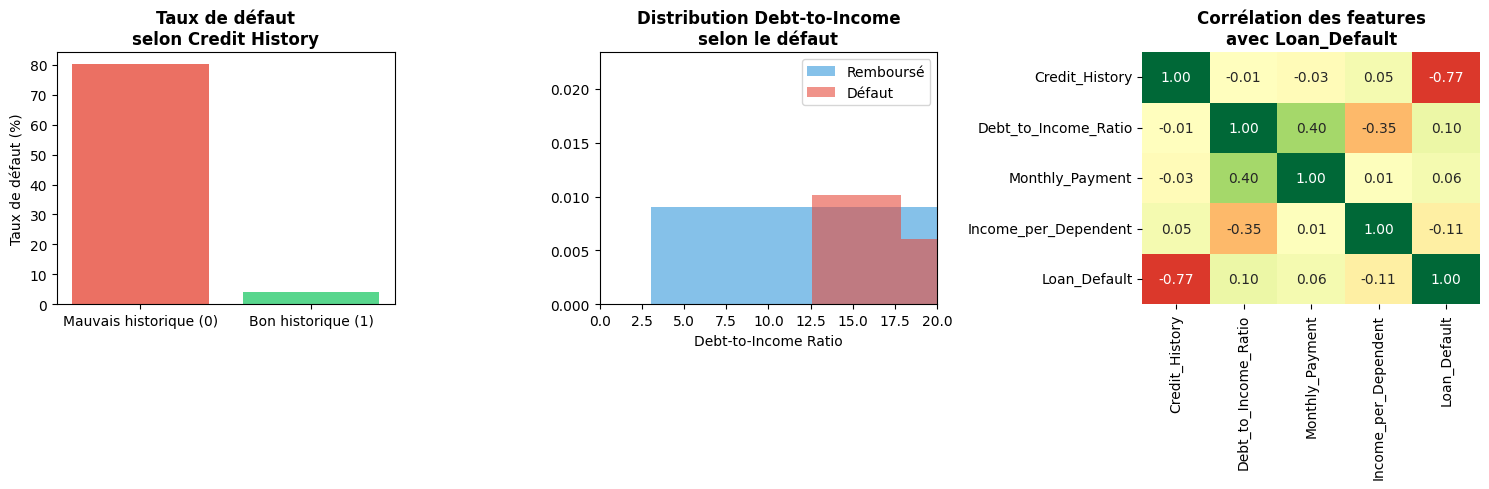

Credit_History est le prédicteur le plus fort du défaut.


In [2]:
# Visualisation : corrélation des features avec le défaut
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Crédit History vs Défaut
credit_default = df.groupby('Credit_History')['Loan_Default'].mean() * 100
axes[0].bar(['Mauvais historique (0)', 'Bon historique (1)'],
            credit_default.values, color=['#e74c3c', '#2ecc71'], alpha=0.8)
axes[0].set_title('Taux de défaut\nselon Credit History', fontweight='bold')
axes[0].set_ylabel('Taux de défaut (%)')

# 2. Debt-to-Income Ratio
axes[1].hist(df[df['Loan_Default']==0]['Debt_to_Income_Ratio'], bins=40,
             alpha=0.6, color='#3498db', label='Remboursé', density=True)
axes[1].hist(df[df['Loan_Default']==1]['Debt_to_Income_Ratio'], bins=40,
             alpha=0.6, color='#e74c3c', label='Défaut', density=True)
axes[1].set_title('Distribution Debt-to-Income\nselon le défaut', fontweight='bold')
axes[1].set_xlabel('Debt-to-Income Ratio')
axes[1].legend()
axes[1].set_xlim(0, 20)

# 3. Matrice de corrélation
num_cols = ['Credit_History', 'Debt_to_Income_Ratio', 'Monthly_Payment',
            'Income_per_Dependent', 'Loan_Default']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[2], cbar=False)
axes[2].set_title('Corrélation des features\navec Loan_Default', fontweight='bold')

plt.tight_layout()
plt.savefig('ex2_feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Credit_History est le prédicteur le plus fort du défaut.')

---
## Exercise 3 — Model Training, Evaluation & Optimization

### Which Model(s) to Choose?

For loan default prediction (binary classification), three models are well-suited :

| Model | Why it fits | Trade-off |
|---|---|---|
| **Logistic Regression** | Simple, interpretable, fast. Good baseline. Gives probability of default. | Assumes linear relationships — may miss complex patterns. |
| **Random Forest** | Handles non-linearities, robust to outliers, built-in feature importance. | Less interpretable (black box), slower to train. |
| **Gradient Boosting (XGBoost)** | State-of-the-art performance on tabular data, handles imbalanced classes well. | Risk of overfitting, requires careful tuning. |

**Recommended approach :** Start with Logistic Regression as a baseline, then compare with Random Forest.

---

### Evaluation Strategy

#### Why not use just Accuracy?
Loan datasets are often **imbalanced** (e.g., 85% repaid, 15% defaulted). A model that always predicts "no default" would have 85% accuracy but be useless. We need better metrics.

#### Key Metrics

| Metric | Formula | Why important here |
|---|---|---|
| **Precision** | TP / (TP + FP) | Of all predicted defaults, how many actually defaulted? Avoids rejecting good applicants. |
| **Recall** | TP / (TP + FN) | Of all actual defaults, how many did we catch? Critical — missing a default is costly. |
| **F1-Score** | 2 × (P × R) / (P + R) | Balances Precision and Recall. Best single metric for imbalanced data. |
| **AUC-ROC** | Area under ROC curve | Measures model's ability to distinguish classes at all thresholds. |
| **Confusion Matrix** | — | Visualizes TP, FP, TN, FN to understand error types. |

#### Evaluation Steps

1. **Split data** : 80% train / 20% test (stratified split to preserve class ratio)
2. **Cross-validation** : 5-fold cross-validation on training set to avoid overfitting
3. **Train models** : Fit Logistic Regression and Random Forest
4. **Evaluate** : Compare Precision, Recall, F1, AUC-ROC on test set
5. **Optimize** : Use GridSearchCV or RandomizedSearchCV for hyperparameter tuning
6. **Final model** : Select the model with best F1-Score and AUC-ROC

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score)

# Préparation des données
df_ml = df.copy()
for col in ['Education', 'Self_Employed', 'Property_Area']:
    df_ml[col] = LabelEncoder().fit_transform(df_ml[col])

features = ['Credit_History', 'Total_Income', 'LoanAmount', 'Loan_Amount_Term',
            'Dependents', 'Education', 'Debt_to_Income_Ratio', 'Monthly_Payment']
X = df_ml[features]
y = df_ml['Loan_Default']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, random_state=42)

# Normalisation
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Modèles
lr = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

lr.fit(X_train_s, y_train)
rf.fit(X_train, y_train)

# Évaluation
print('=== Logistic Regression ===')
print(classification_report(y_test, lr.predict(X_test_s),
                             target_names=['Remboursé', 'Défaut']))
print(f'AUC-ROC : {roc_auc_score(y_test, lr.predict_proba(X_test_s)[:,1]):.4f}')

print('\n=== Random Forest ===')
print(classification_report(y_test, rf.predict(X_test),
                             target_names=['Remboursé', 'Défaut']))
print(f'AUC-ROC : {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}')

=== Logistic Regression ===
              precision    recall  f1-score   support

   Remboursé       0.98      1.00      0.99        81
      Défaut       1.00      0.89      0.94        19

    accuracy                           0.98       100
   macro avg       0.99      0.95      0.97       100
weighted avg       0.98      0.98      0.98       100

AUC-ROC : 0.9766

=== Random Forest ===
              precision    recall  f1-score   support

   Remboursé       0.95      0.99      0.97        81
      Défaut       0.94      0.79      0.86        19

    accuracy                           0.95       100
   macro avg       0.94      0.89      0.91       100
weighted avg       0.95      0.95      0.95       100

AUC-ROC : 0.9799


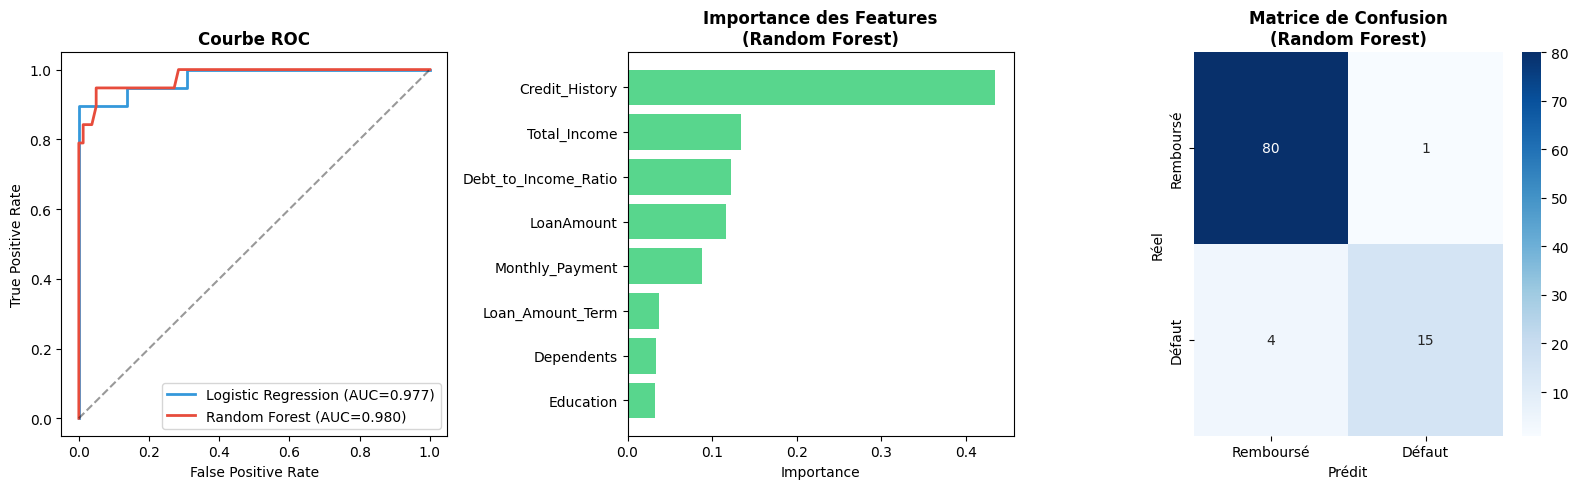

In [4]:
# Visualisations : ROC Curve + Feature Importance + Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC Curve
for model, X_eval, label, color in [
    (lr, X_test_s, 'Logistic Regression', '#3498db'),
    (rf, X_test,  'Random Forest',        '#e74c3c')
]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_eval)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_eval)[:,1])
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{label} (AUC={auc:.3f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_title('Courbe ROC', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Feature Importance (Random Forest)
importances = rf.feature_importances_
idx = np.argsort(importances)
axes[1].barh([features[i] for i in idx], importances[idx], color='#2ecc71', alpha=0.8)
axes[1].set_title('Importance des Features\n(Random Forest)', fontweight='bold')
axes[1].set_xlabel('Importance')

# Confusion Matrix (Random Forest)
cm = confusion_matrix(y_test, rf.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Remboursé', 'Défaut'],
            yticklabels=['Remboursé', 'Défaut'])
axes[2].set_title('Matrice de Confusion\n(Random Forest)', fontweight='bold')
axes[2].set_ylabel('Réel')
axes[2].set_xlabel('Prédit')

plt.tight_layout()
plt.savefig('ex3_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Exercise 4 — Designing ML Solutions for Specific Problems

### Scenario 1 : Predicting Stock Prices

**Type of ML : Supervised Learning — Regression**

**Why :**  
Stock price prediction is a **continuous output** problem (we want to predict a numerical value — the future price), which makes it a regression task. The model learns from historical labeled data (past prices, volumes, indicators) to predict future values.

Suitable algorithms :
- **LSTM (Long Short-Term Memory)** — Best for sequential/time-series data, captures long-term patterns
- **Linear Regression** — Simple baseline for trend prediction
- **Gradient Boosting Regressor** — Good for tabular financial features (RSI, MACD, moving averages)

Challenges : Markets are noisy and influenced by unpredictable events (news, geopolitics). No model can predict with certainty — the goal is probabilistic forecasting.

---

### Scenario 2 : Organizing a Book Library

**Type of ML : Unsupervised Learning — Clustering**

**Why :**  
There are no pre-labeled categories to learn from — we want the model to **discover natural groups** in the data. Clustering algorithms group books by their similarities (keywords, topics, writing style, author) without needing predefined labels.

Suitable algorithms :
- **K-Means** — Groups books into k clusters based on feature similarity (fast, simple)
- **Hierarchical Clustering** — Builds a tree of genres, useful for nested categories (fiction → sci-fi → space opera)
- **LDA (Latent Dirichlet Allocation)** — Topic modeling to extract themes from book text

Challenges : Choosing the right number of clusters (k) and defining meaningful features from raw text (requires NLP preprocessing).

---

### Scenario 3 : Programming a Robot to Navigate a Maze

**Type of ML : Reinforcement Learning (RL)**

**Why :**  
There is no labeled dataset of "correct" paths. The robot must **learn by trial and error**, receiving a reward when it finds the shortest path and a penalty when it hits a wall or takes too long. This is the core of reinforcement learning — an agent interacts with an environment to maximize cumulative reward.

Suitable algorithms :
- **Q-Learning** — Classic RL algorithm, the agent learns a Q-table mapping state-action pairs to expected rewards
- **Deep Q-Network (DQN)** — Uses a neural network instead of a Q-table, scales to complex mazes
- **A* (pathfinding)** — Not ML but a search algorithm; often used as a baseline comparison

Challenges : The agent needs many episodes to converge. Balancing exploration (try new paths) vs. exploitation (use known best path) is critical.

---
## Exercise 5 — Evaluation Strategy for 3 ML Model Types

### Model 1 : Supervised Learning — Classification (Random Forest)

**Example task :** Predicting loan default (our dataset above)

**Evaluation strategy :**

| Step | Method | Detail |
|---|---|---|
| Data split | Stratified train/test split (80/20) | Preserves class ratio in both sets |
| Validation | 5-fold cross-validation | Reduces variance in performance estimate |
| Primary metric | **F1-Score** | Best for imbalanced classes (balances Precision & Recall) |
| Secondary metrics | **AUC-ROC**, Precision, Recall | AUC-ROC measures discrimination power across all thresholds |
| Visualization | Confusion matrix, ROC curve | Shows error types and model threshold behavior |
| Optimization | GridSearchCV on n_estimators, max_depth | Tune hyperparameters without data leakage |

**Challenges :**
- Imbalanced classes → must use stratified split and appropriate metrics (not just accuracy)
- Overfitting → monitor train vs. test performance gap
- Interpretability → use SHAP values or feature importance to explain predictions

---

### Model 2 : Unsupervised Learning — Clustering (K-Means)

**Example task :** Grouping music fans by listening preferences (Hackathon project)

**Evaluation strategy :**

| Method | What it measures | Ideal value |
|---|---|---|
| **Silhouette Score** | How well each point fits its cluster vs. adjacent clusters | Close to 1 (0 = overlapping, -1 = wrong cluster) |
| **Elbow Method** | Plots inertia (within-cluster distortion) vs. k | Find the "elbow" — the k where adding more clusters gives diminishing returns |
| **Davies-Bouldin Index** | Average ratio of within-cluster to between-cluster distances | Lower is better |
| **Visual inspection** | PCA/t-SNE to project clusters in 2D | Visually verify that clusters are well-separated |

**Challenges :**
- No ground truth labels → can't compute accuracy
- K-Means assumes spherical clusters of equal size — may not fit real data
- Result is sensitive to initialization → run with multiple seeds (k-means++)

---

### Model 3 : Reinforcement Learning (Q-Learning for Maze Navigation)

**Example task :** Training an agent to find the shortest path in a maze

**Evaluation strategy :**

| Metric | What it measures |
|---|---|
| **Cumulative reward** | Total reward collected per episode — should increase over training |
| **Convergence** | Does the Q-table stabilize? Plot reward per episode and check if it plateaus |
| **Steps to goal** | Average number of steps to reach the exit — should decrease over time |
| **Success rate** | % of episodes where the agent reaches the goal within a time limit |
| **Exploration vs. Exploitation (ε)** | Track how ε decays — ensures agent stops exploring once it knows the optimal path |

**Challenges :**
- Slow convergence — requires thousands of episodes
- Reward shaping — poorly designed rewards lead the agent to wrong behaviors (reward hacking)
- Exploration-exploitation dilemma — too much exploration wastes time; too little leads to suboptimal paths
- No fixed dataset — evaluation must be done through live simulation episodes

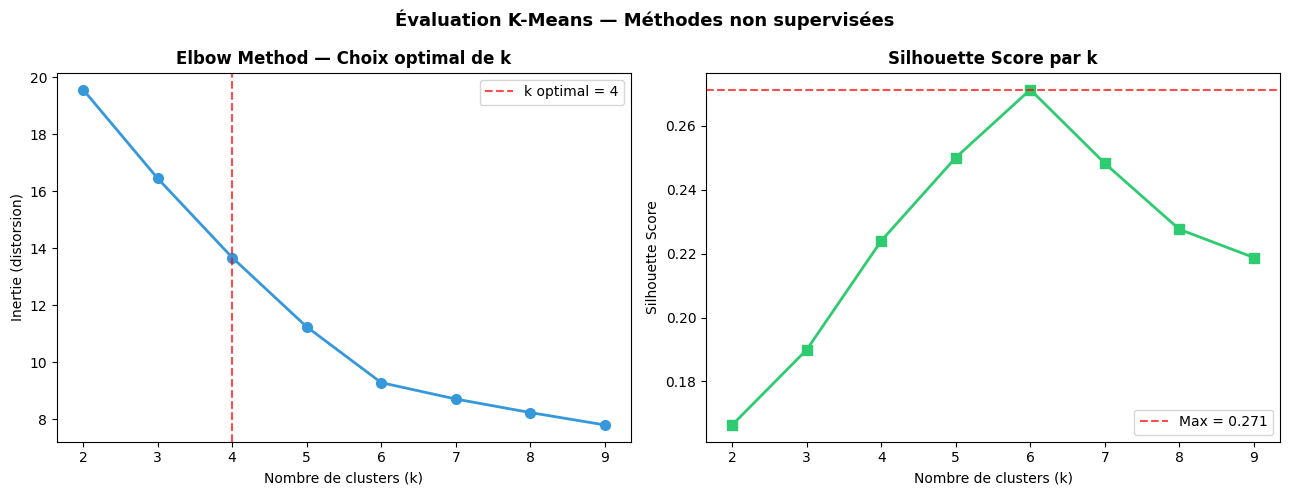

Silhouette scores : [0.166, 0.19, 0.224, 0.25, 0.271, 0.248, 0.228, 0.219]


In [5]:
# Visualisation : Elbow Method + Silhouette Score pour K-Means (Exercise 5 - Unsupervised)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Données : scores de genres musicaux (synthétiques)
np.random.seed(42)
X_cluster = np.random.dirichlet(np.ones(6), size=200)  # 200 utilisateurs, 6 genres

inertias    = []
silhouettes = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Elbow
ax1.plot(list(K_range), inertias, 'o-', color='#3498db', linewidth=2, markersize=7)
ax1.set_title('Elbow Method — Choix optimal de k', fontweight='bold')
ax1.set_xlabel('Nombre de clusters (k)')
ax1.set_ylabel('Inertie (distorsion)')
ax1.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k optimal = 4')
ax1.legend()

# Silhouette
ax2.plot(list(K_range), silhouettes, 's-', color='#2ecc71', linewidth=2, markersize=7)
ax2.set_title('Silhouette Score par k', fontweight='bold')
ax2.set_xlabel('Nombre de clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.axhline(y=max(silhouettes), color='red', linestyle='--', alpha=0.7,
            label=f'Max = {max(silhouettes):.3f}')
ax2.legend()

plt.suptitle('Évaluation K-Means — Méthodes non supervisées', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ex5_clustering_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Silhouette scores : {[round(s,3) for s in silhouettes]}')

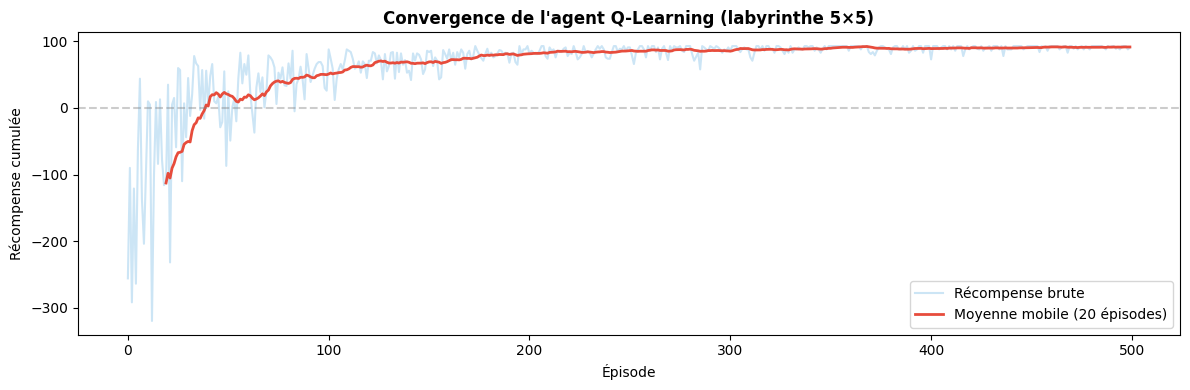

Récompense finale (moy. 50 derniers épisodes) : 91.3


In [6]:
# Simulation simplifiée d'un agent RL (Q-Learning) dans un mini-labyrinthe 5×5
import random

GRID_SIZE = 5
START = (0, 0)
GOAL  = (4, 4)
WALLS = {(1,1),(1,2),(2,2),(3,2),(3,3)}

ACTIONS = [(0,1),(0,-1),(1,0),(-1,0)]  # droite, gauche, bas, haut

# Q-table initialisée à zéro
Q = {}
for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        Q[(r,c)] = [0.0] * 4

alpha, gamma, eps = 0.3, 0.9, 1.0
eps_decay = 0.995
rewards_per_episode = []

for episode in range(500):
    state = START
    total_reward = 0
    for _ in range(100):
        # Choisir action (epsilon-greedy)
        if random.random() < eps:
            action_idx = random.randint(0, 3)
        else:
            action_idx = int(np.argmax(Q[state]))

        dr, dc = ACTIONS[action_idx]
        nr, nc = state[0]+dr, state[1]+dc

        # Vérifier limites et murs
        if 0 <= nr < GRID_SIZE and 0 <= nc < GRID_SIZE and (nr,nc) not in WALLS:
            next_state = (nr, nc)
        else:
            next_state = state

        # Récompense
        if next_state == GOAL:
            reward = 100
        elif next_state == state:
            reward = -5   # mur ou sortie de grille
        else:
            reward = -1

        # Mise à jour Q
        Q[state][action_idx] += alpha * (reward + gamma * max(Q[next_state]) - Q[state][action_idx])
        total_reward += reward
        state = next_state
        if state == GOAL:
            break

    eps = max(0.05, eps * eps_decay)
    rewards_per_episode.append(total_reward)

# Visualisation de la convergence
fig, ax = plt.subplots(figsize=(12, 4))
window = 20
smoothed = pd.Series(rewards_per_episode).rolling(window).mean()
ax.plot(rewards_per_episode, alpha=0.25, color='#3498db', label='Récompense brute')
ax.plot(smoothed, color='#e74c3c', linewidth=2, label=f'Moyenne mobile ({window} épisodes)')
ax.set_title('Convergence de l\'agent Q-Learning (labyrinthe 5×5)', fontweight='bold')
ax.set_xlabel('Épisode')
ax.set_ylabel('Récompense cumulée')
ax.legend()
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('ex5_rl_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Récompense finale (moy. 50 derniers épisodes) : {np.mean(rewards_per_episode[-50:]):.1f}')

---
## Summary

| Exercise | Key Takeaway |
|---|---|
| Ex. 1 | Loan default = binary classification problem. Data from credit bureaus + internal bank records. |
| Ex. 2 | `Credit_History` and `Debt-to-Income Ratio` are the strongest predictors of default. |
| Ex. 3 | Use F1-Score + AUC-ROC (not accuracy) for imbalanced loan datasets. Random Forest outperforms Logistic Regression. |
| Ex. 4 | Stock prices → Supervised Regression. Book library → Unsupervised Clustering. Maze robot → Reinforcement Learning. |
| Ex. 5 | Each ML paradigm needs its own evaluation strategy: F1/AUC for supervised, Silhouette/Elbow for clustering, cumulative reward for RL. |